In [339]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime
import scrfft  # Ensure this is installed and functional
import seaborn as sns

In [340]:
def scrfft(xdata,ydata):
    sdata=np.argsort(xdata)
    xdatas=xdata[sdata]
    ydatas=ydata[sdata]
    
    
    xmin=np.min(xdata)
    xmax=np.max(xdata)
    ndata=len(xdata)
    x=(xmax-xmin)/(ndata-1)*np.arange(ndata)+xmin
    y=np.interp(x,xdatas,ydatas)
    
    yf = 2.0*np.fft.rfft(y)/(ndata+1)
    a=np.real(yf)
    b=-np.imag(yf)
    yf=0
    
    a[0]=0.5*a[0]
    
    f=np.arange(len(a))/(xmax-xmin)
    
    return(f, a, b)

In [341]:
# read the data
fds = pd.read_csv('airline3.csv')

# add grid
sns.set(style ="darkgrid")

In [342]:
# check the datatype
fds.dtypes

Date       object
Number    float64
Price     float64
dtype: object

In [343]:
# Parse dates and create the required inputs
fds['Date'] = pd.to_datetime(fds['Date'])  # Convert to datetime
month = fds['Date'].dt.month       # Extract month
dates = fds['Date']
dp = fds['Number'].astype(float)          # Ensure Passenger column is float

In [344]:
# Convert dates to numerical values
dates_num = mdates.date2num(dates)
ndata = len(dp)

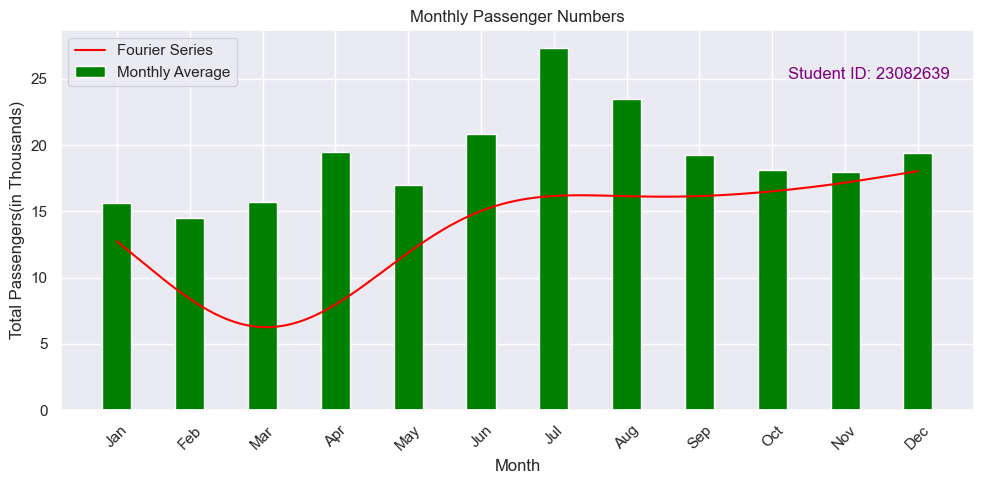

In [345]:
# Perform Fourier Transform (assuming scrfft is configured correctly)
freqs, ccoef, scoef = scrfft(fds.index, fds['Number'])

# Fourier fit
myfourierfit = np.zeros(ndata)
for i in range(8):  # Fit first 5 Fourier components
    myfourierfit += (
        ccoef[i] * np.cos(2 * np.pi * freqs[i] * fds.index) +
        scoef[i] * np.sin(2 * np.pi * freqs[i] * fds.index)
    )
    
# Parse dates
fds['Date'] = pd.to_datetime(fds['Date'])  # Convert to datetime
fds['month'] = fds['Date'].dt.month       # Extract month

# Filter data for 3 years
year_data = fds[(fds['Date'] > '2020-12-31') & (fds['Date'] < '2024-01-01')]

# Aggregate data by month
monthly_counts = year_data.groupby('month')['Number'].mean().reset_index()
months = monthly_counts['month']
passenger_counts = monthly_counts['Number']

# Create the bar plot
fig = plt.figure(figsize=(10, 5))

# Creating the bar plot
plt.bar(months, passenger_counts, color='green', width=0.4, label = "Monthly Average")
myfourierfit=myfourierfit[0:365]
plt.plot(np.linspace(1,12,365),myfourierfit, color='red', label = "Fourier Series")


# Labeling the axes and the title
plt.xlabel("Month")
plt.ylabel("Total Passengers(in Thousands)")
plt.title("Monthly Passenger Numbers")

# Adjust x-axis labels
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

# Add student ID annotation
plt.text(12.5,25, "Student ID: 23082639 ", fontsize = 12, color = 'purple', horizontalalignment = 'right')

# add legend
plt.legend(loc = "upper left")

# Show the plot
plt.tight_layout()
plt.savefig("Fourier.png", dpi = 600)
plt.show()


18239600.0
19968980.0


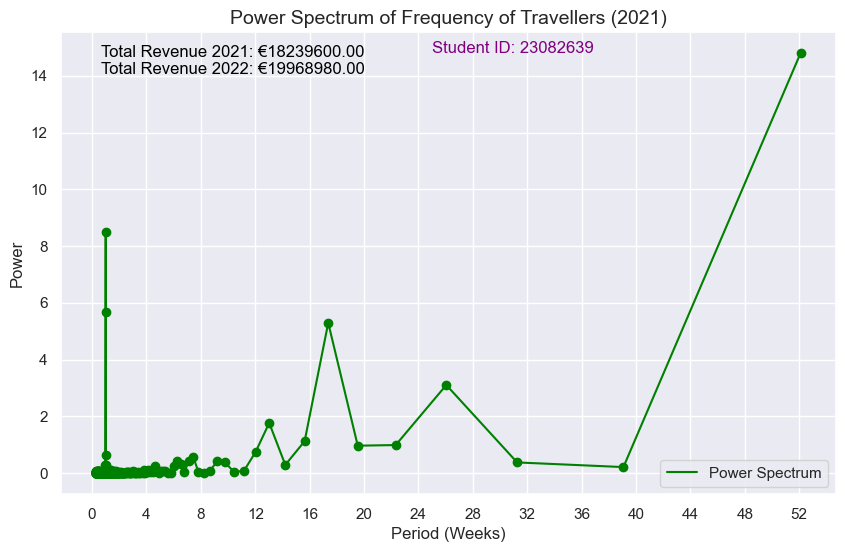

In [346]:
def plot_power_spectrum(fds):
    '''
    Plots a power spectrum of the frequencies.
    Calculates the Average Revenue and length of the main period
    '''
    freqs, ccoef, scoef = scrfft(fds.index,fds['Number'])
    
    # Converting Frequency to Period in weeks and weeks 
    timeperiod = 1 / (freqs[1:] * 7)
    timeperiod_52 = timeperiod[timeperiod<53]
    timeperiod
 
    #Computing the power and filtering for the time period of 1 year
    spower = ccoef**2+scoef**2
    spower = spower[3:]
    spower

    # Extract month
    fds['year'] = fds['Date'].dt.year  

    # to calculate X and Y
    total_revenue = fds.groupby('year').sum('Price')
    
    revenue_2021 = total_revenue[total_revenue.index==2021]["Price"].values
    rev_2021=revenue_2021[0]*1000
    print(rev_2021)

    revenue_2022 = total_revenue[total_revenue.index==2022]["Price"].values
    rev_2022=revenue_2022[0]*1000
    print(rev_2022)
    
    #Power spectrum plot with weeks on the X-axis
    plt.figure(figsize = (10, 6))
    plt.plot(timeperiod_52, spower, color='green', label="Power Spectrum")  # Frequency in weeks
    plt.scatter(timeperiod_52, spower, color='green')

    plt.xticks(np.arange(0,53,step = 4))
    plt.xlabel('Period (Weeks)', fontsize = 12)
    plt.ylabel('Power', fontsize = 12)
    plt.title('Power Spectrum of Frequency of Travellers (2021)', fontsize = 14)
    plt.text(0.69, 0.95 * max(spower), f"Total Revenue 2021: €{rev_2021:.2f}\nTotal Revenue 2022: €{rev_2022:.2f}", fontsize = 12, color='black')

    # Add student ID annotation
    plt.text(25, max(spower), "Student ID: 23082639 ", fontsize = 12, color = 'purple', horizontalalignment = 'left')
    plt.legend(loc="lower right")
    plt.savefig("power spectrum.png", dpi = 600)
    plt.show()




plot_power_spectrum(fds)